# NBA球员数据分析与聚类挖掘
## 角色C：无监督学习与聚类挖掘


### 0. 环境配置与数据加载


```python

In [64]:
# 基础库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 机器学习库
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import json
import os

print("所有库导入成功！")

所有库导入成功！


In [65]:
# 加载角色A处理好的主数据集
df = pd.read_csv('../data/processed/master_data.csv')

print(f"数据形状: {df.shape}")
print(f"年份范围: {df['Year'].min()} - {df['Year'].max()}")
print(f"球员数量: {df['Player'].nunique()}")
print(f"\n列名概览:\n{df.columns.tolist()[:20]}...")

# 查看数据基本信息
print("\n数据基本信息:")
df.info()

# 查看缺失值情况
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"\n存在缺失值的列数: {len(missing)}")
print(missing.head(15))

数据形状: (20313, 78)
年份范围: 1950 - 2017
球员数量: 3921

列名概览:
['Year', 'Player', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%']...

数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20313 entries, 0 to 20312
Data columns (total 78 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             20313 non-null  int64  
 1   Player           20313 non-null  object 
 2   Pos              20313 non-null  object 
 3   Age              20307 non-null  float64
 4   Tm               20313 non-null  object 
 5   G                20313 non-null  float64
 6   GS               20313 non-null  float64
 7   MP               20313 non-null  float64
 8   PER              19921 non-null  float64
 9   TS%              20269 non-null  float64
 10  3PAr             15500 non-null  float64
 11  FTr              20261 non-null  float64
 12  ORB%             17096 non-

### 1. 数据预处理与特征工程


#### 1.1 定义年代分段

In [66]:
# 定义年代分段函数
def assign_era(year):
    if year < 1980:
        return '1970s'
    elif year < 1990:
        return '1980s'
    elif year < 2000:
        return '1990s'
    elif year < 2010:
        return '2000s'
    else:
        return '2010s'

df['Era'] = df['Year'].apply(assign_era)

# 查看各年代数据量
print("各年代数据量:")
print(df['Era'].value_counts().sort_index())

各年代数据量:
Era
1970s    4769
1980s    3198
1990s    4103
2000s    4466
2010s    3777
Name: count, dtype: int64


#### 1.2 定义聚类特征

In [67]:
# 核心聚类特征（比率型指标，消除出场时间影响）
# 目标：捕捉球员的"功能性"而非"产量"
CLUSTER_FEATURES = [
    # 效率与产量
    'PER',           # 球员效率值
    'TS%',           # 真实命中率
    'USG%',          # 使用率
    
    # 投篮分布
    '3PAr',          # 三分出手占比
    'FTr',           # 罚球率（侵略性）
    
    # 进阶贡献率
    'AST%',          # 助攻率
    'TRB%',          # 篮板率
    'STL%',          # 抢断率
    'BLK%',          # 盖帽率
    
    # 高阶影响
    'OBPM',          # 进攻BPM
    'DBPM',          # 防守BPM
    'VORP',          # 价值替代球员
]

print(f"共选择 {len(CLUSTER_FEATURES)} 个聚类特征:")
print(CLUSTER_FEATURES)

共选择 12 个聚类特征:
['PER', 'TS%', 'USG%', '3PAr', 'FTr', 'AST%', 'TRB%', 'STL%', 'BLK%', 'OBPM', 'DBPM', 'VORP']


#### 1.3 数据清洗

In [68]:
def prepare_clustering_data(df, features, min_mp=800):
    """
    准备聚类数据
    - 筛选出场时间足够的球员（排除饮水机管理员）
    - 剔除缺失值
    - 返回清洗后的数据和对应的球员标识
    """
    # 筛选出场时间
    df_filtered = df[df['MP'] >= min_mp].copy()
    print(f"过滤出场时间<{min_mp}分钟后，剩余 {len(df_filtered)} 行")
    
    # 筛选特征列
    df_features = df_filtered[features].copy()
    
    # 剔除缺失值
    valid_idx = df_features.dropna().index
    df_clean = df_filtered.loc[valid_idx].copy()
    df_features_clean = df_features.loc[valid_idx].copy()
    
    print(f"剔除缺失值后，剩余 {len(df_clean)} 行")
    
    return df_clean, df_features_clean
  


# 准备数据
df_clean, df_features_clean = prepare_clustering_data(df, CLUSTER_FEATURES)

# 保存球员标识信息
player_labels = df_clean[['Year', 'Player', 'Pos', 'Tm', 'Era']].reset_index(drop=True)

过滤出场时间<800分钟后，剩余 13007 行
剔除缺失值后，剩余 9888 行


### 2. 按年代分段聚类


#### 2.1 创建分段聚类函数

In [69]:
# 手动指定各年代的K值（基于篮球业务知识）
K_BY_ERA = {
    '1980s': 5,   # 传统五位置
    '1990s': 5,   # 传统五位置
    '2000s': 6,   # 增加3D侧翼
    '2010s': 7,   # 进一步细分
}

def cluster_by_era_manual(df, features, era_name, n_clusters):
    """
    手动指定K值的聚类函数
    """
    print(f"\n{'='*50}")
    print(f"正在处理 {era_name} 数据 (K={n_clusters})...")
    
    # 筛选年代
    era_df = df[df['Era'] == era_name].copy()
    if len(era_df) < 50:
        print(f"{era_name} 数据量不足 ({len(era_df)}行)，跳过")
        return None
    
    # 提取特征
    era_features = era_df[features].copy()
    era_features_clean = era_features.dropna()
    era_df_clean = era_df.loc[era_features_clean.index].copy()
    
    if len(era_df_clean) < 30:
        print(f"{era_name} 清洗后数据量不足，跳过")
        return None
    
    print(f"清洗后数据量: {len(era_df_clean)}")
    
    # 标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(era_features_clean)
    
    # 使用指定的K值进行聚类
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # 计算轮廓系数（作为参考）
    sil_score = silhouette_score(X_scaled, cluster_labels)
    print(f"轮廓系数: {sil_score:.4f}")
    
    # 保存结果
    result_df = era_df_clean.copy()
    result_df['Cluster'] = cluster_labels
    
    return {
        'era': era_name,
        'data': result_df,
        'scaler': scaler,
        'kmeans': kmeans,
        'labels': cluster_labels,
        'n_clusters': n_clusters,
        'silhouette_score': sil_score,
        'X_scaled': X_scaled,
    }
    


       
    
  
 


#### 2.2 执行分段聚类

In [70]:
# 创建保存模型的目录
os.makedirs('../saved_models', exist_ok=True)
eras = ['1980s', '1990s', '2000s', '2010s']
era_results = {}

for era in eras:
    n_clusters = K_BY_ERA[era]
    result = cluster_by_era_manual(df_clean, CLUSTER_FEATURES, era, n_clusters)
    
    if result is not None:
        era_results[era] = result
        # 保存模型
        joblib.dump(result['kmeans'], f'../saved_models/kmeans_{era}.pkl')
        joblib.dump(result['scaler'], f'../saved_models/scaler_{era}.pkl')

print(f"\n成功完成聚类的年代: {list(era_results.keys())}")


正在处理 1980s 数据 (K=5)...
清洗后数据量: 2205
轮廓系数: 0.1625

正在处理 1990s 数据 (K=5)...
清洗后数据量: 2544
轮廓系数: 0.1493

正在处理 2000s 数据 (K=6)...
清洗后数据量: 2786
轮廓系数: 0.1528

正在处理 2010s 数据 (K=7)...
清洗后数据量: 2353
轮廓系数: 0.1498

成功完成聚类的年代: ['1980s', '1990s', '2000s', '2010s']


#### 2.3 可视化各年代聚类结果

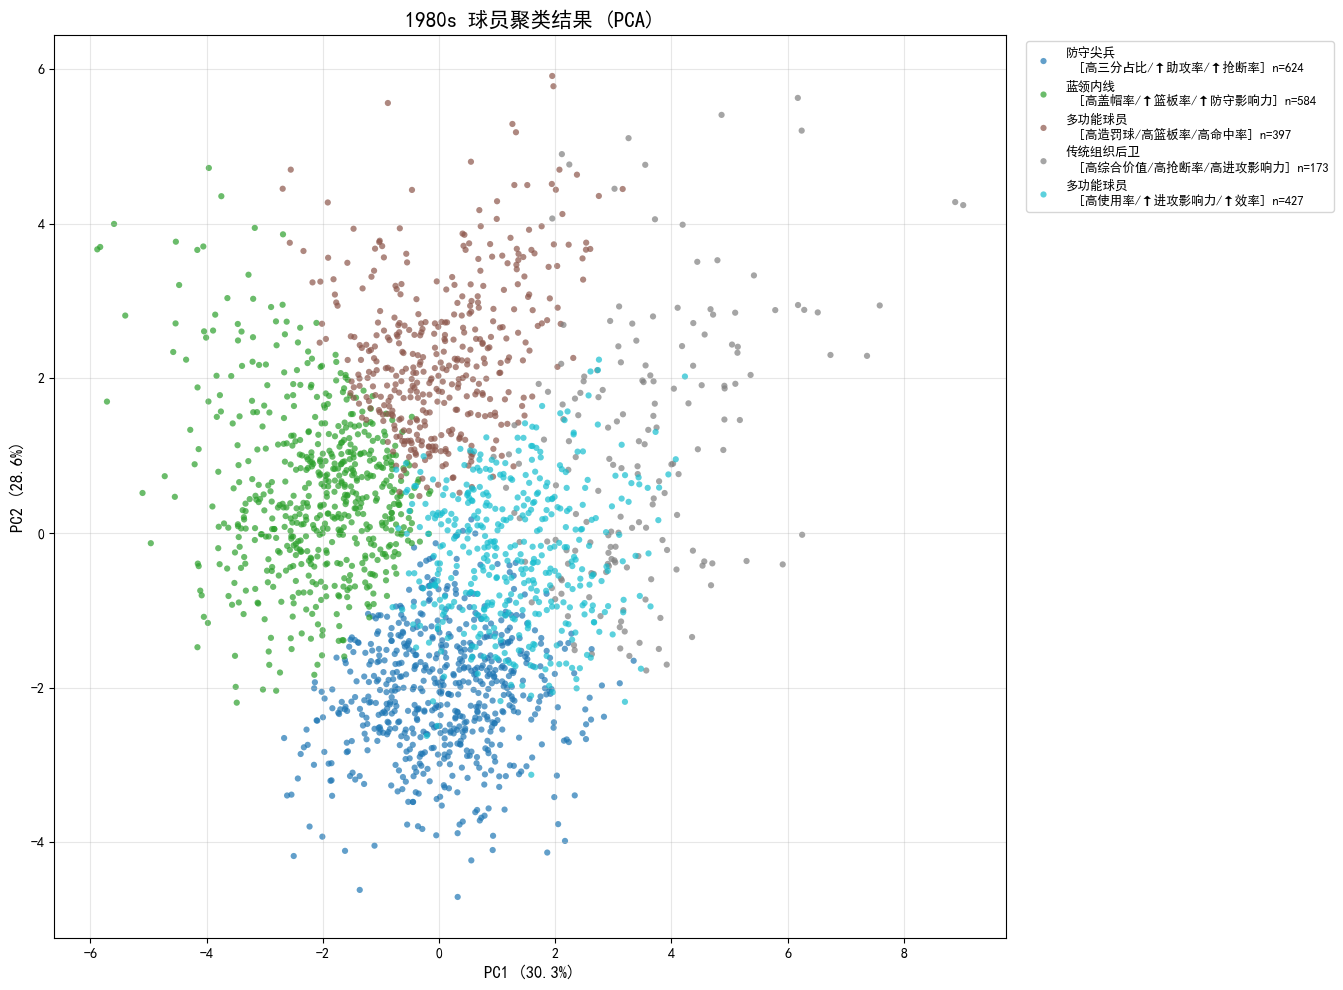

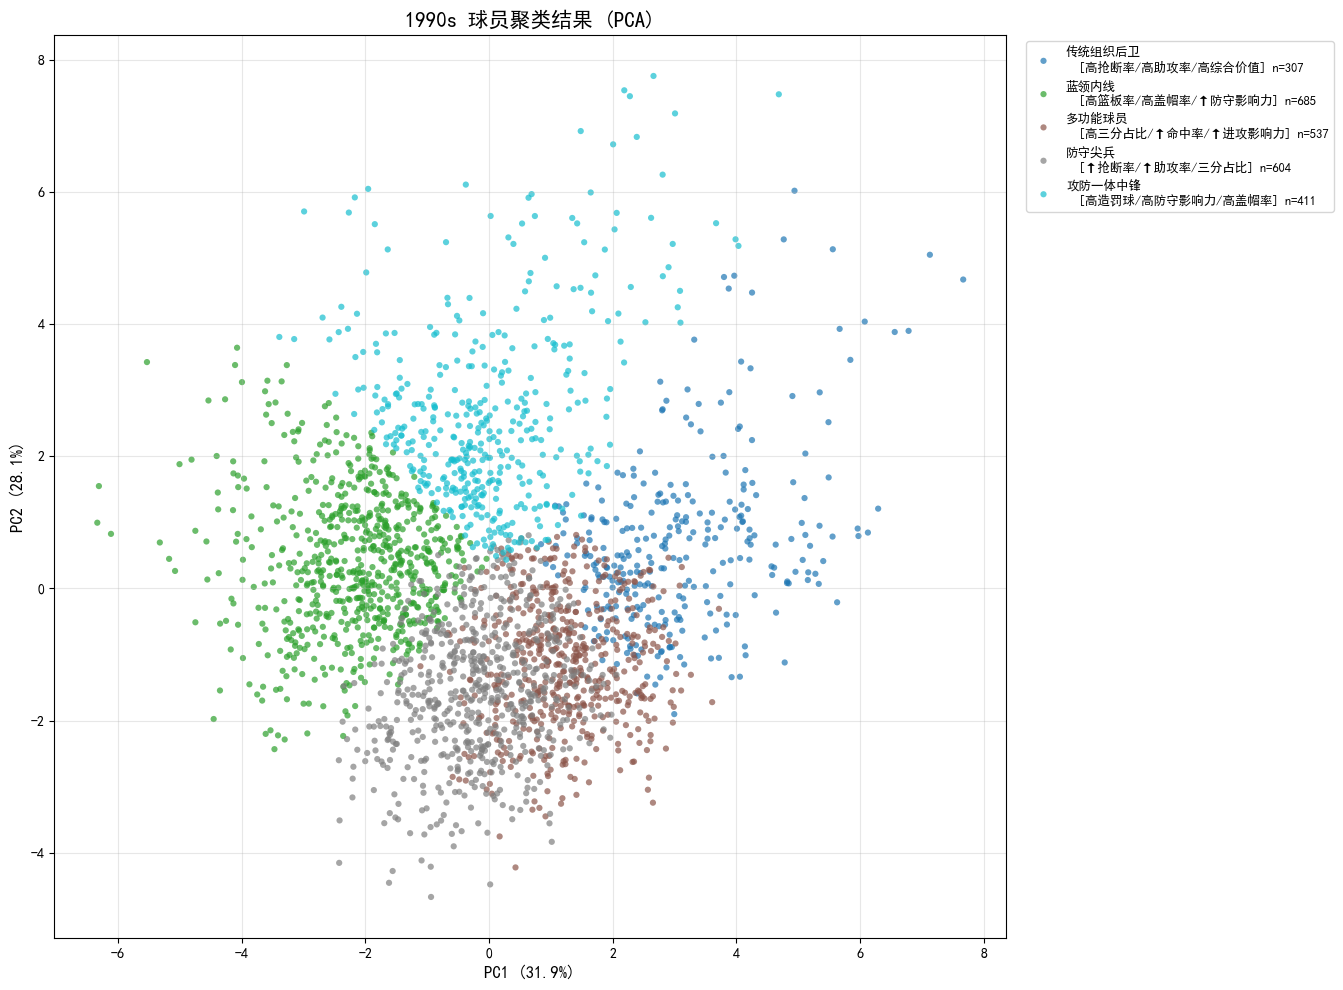

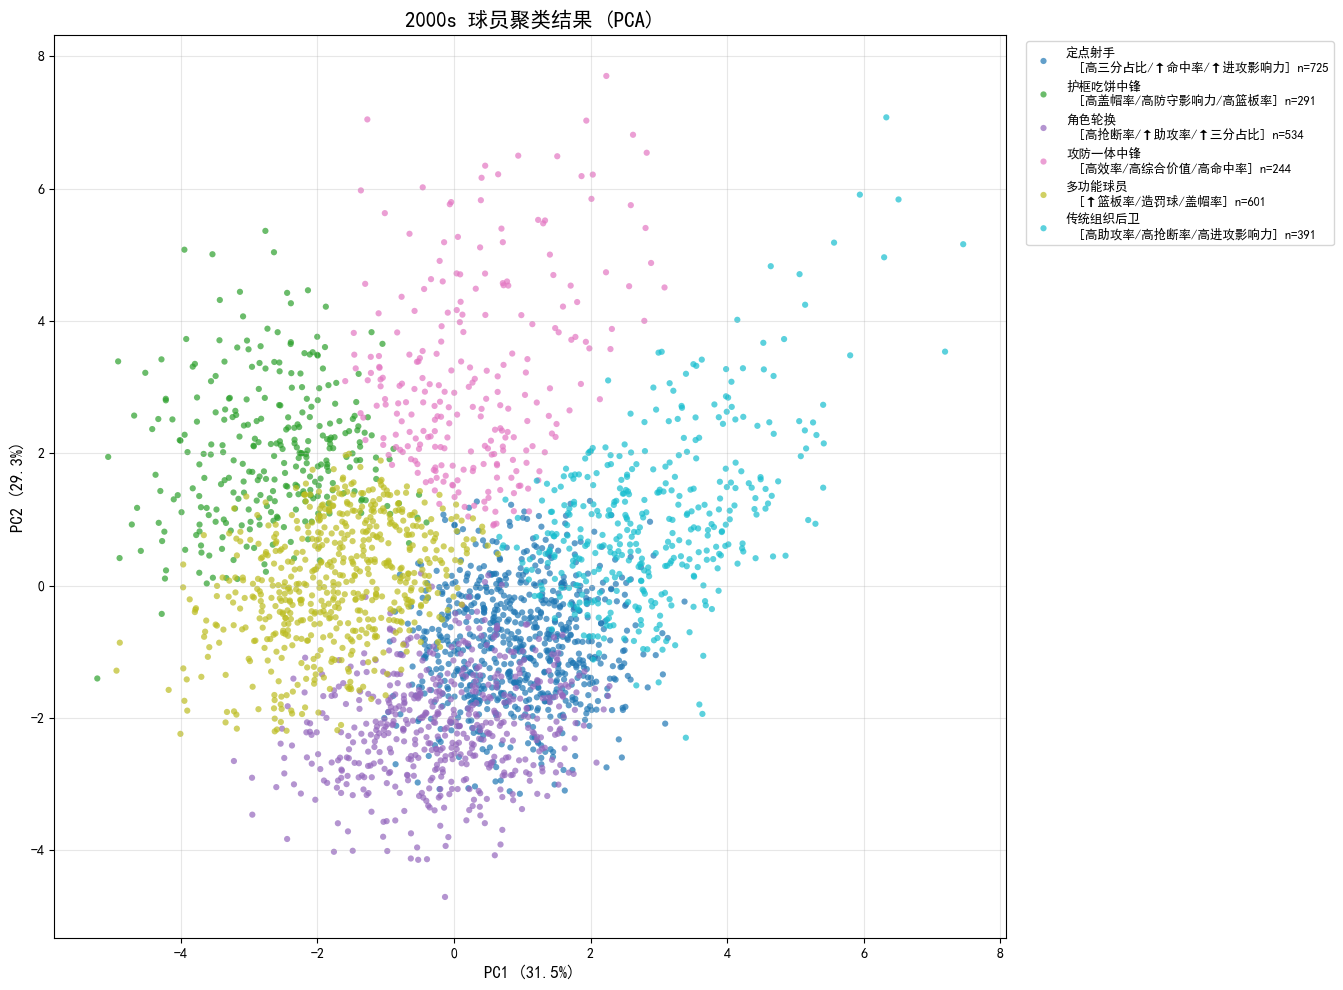

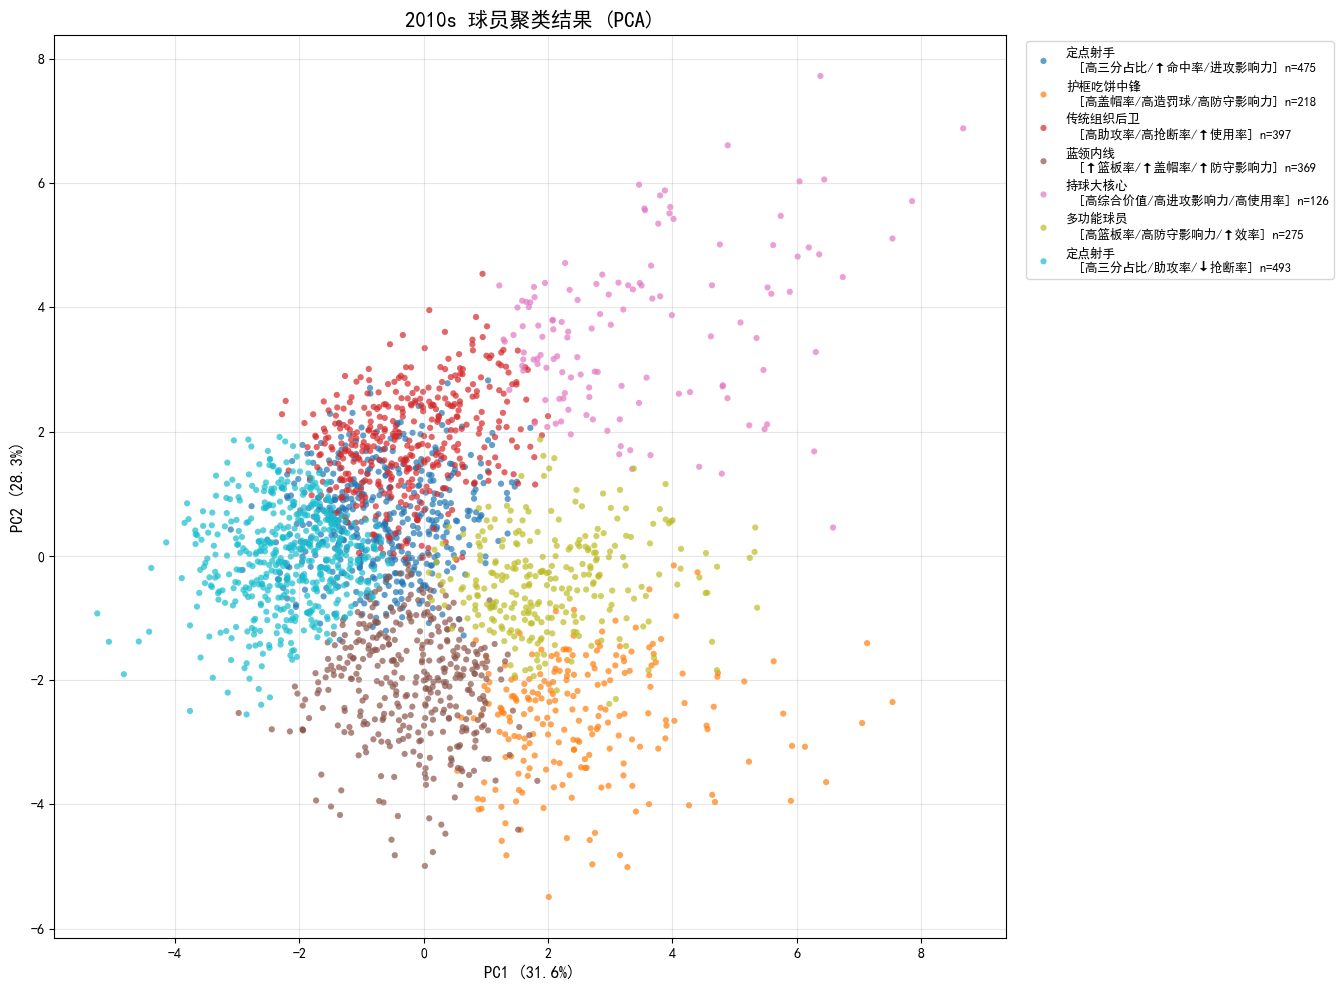

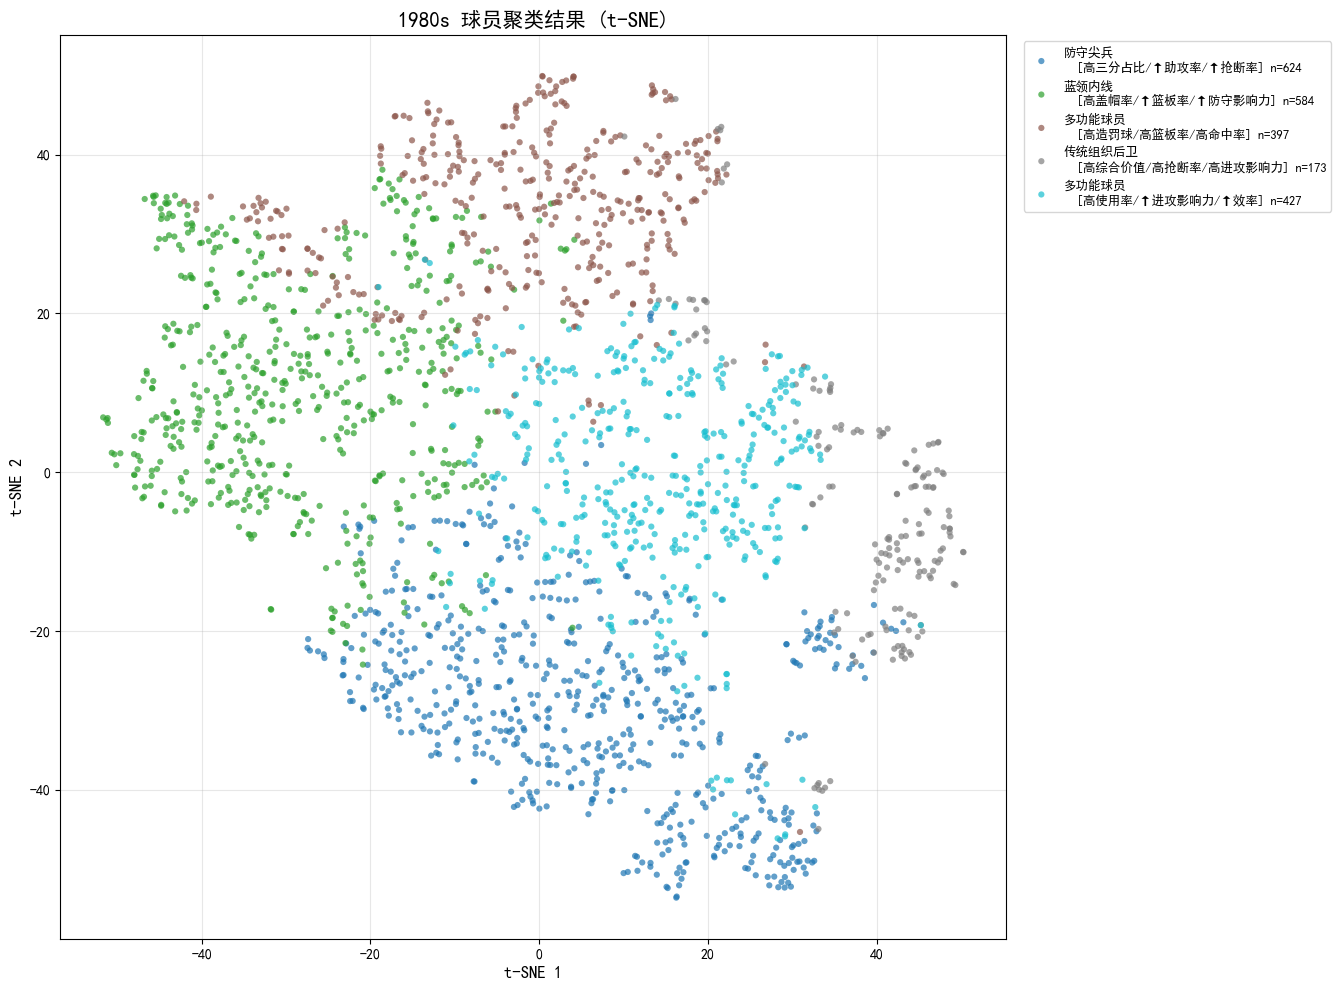

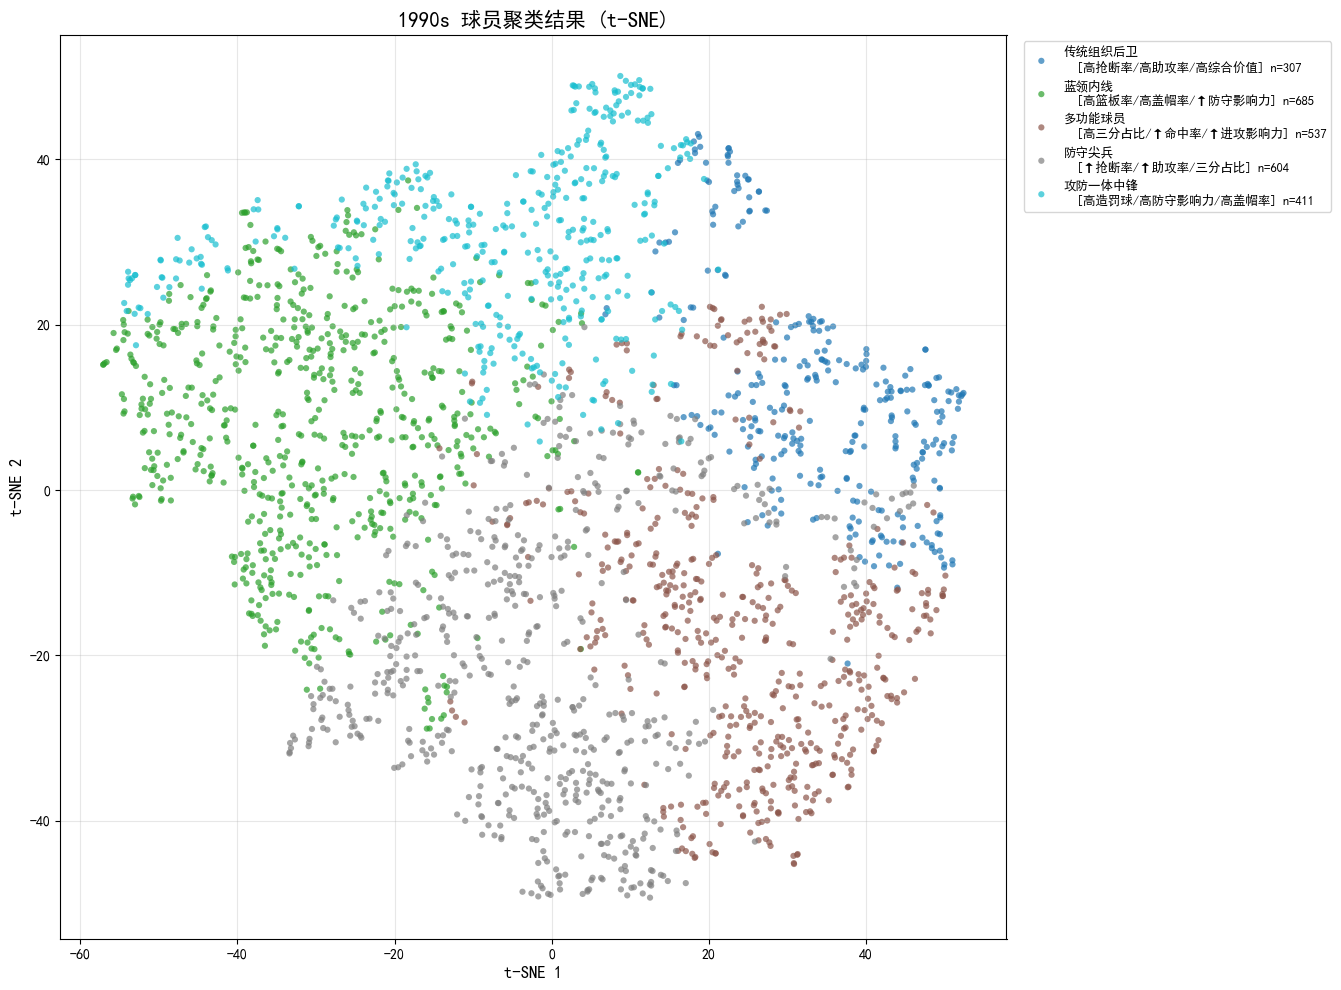

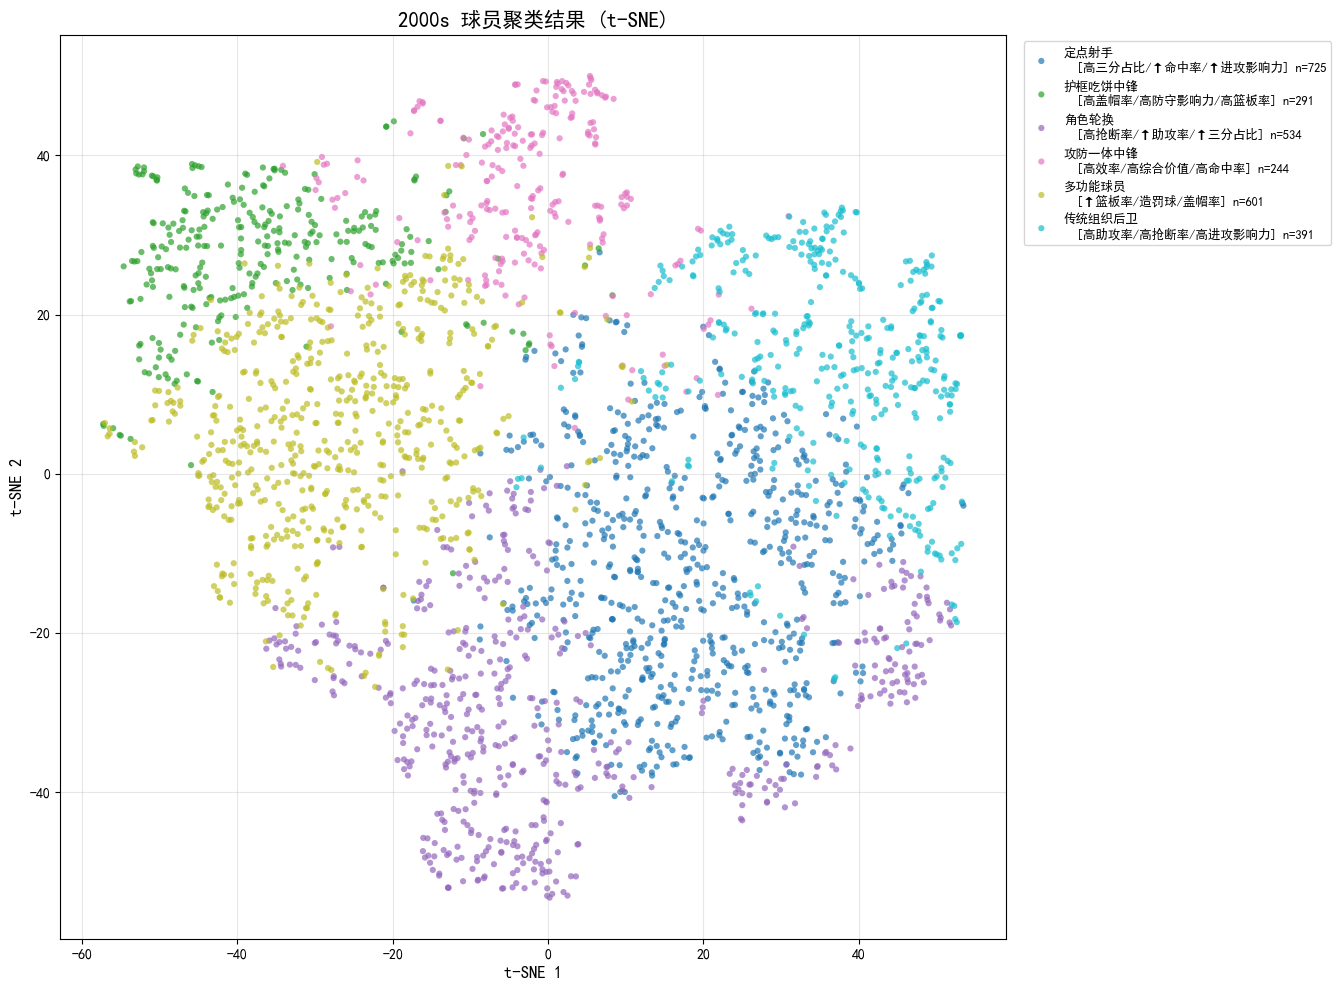

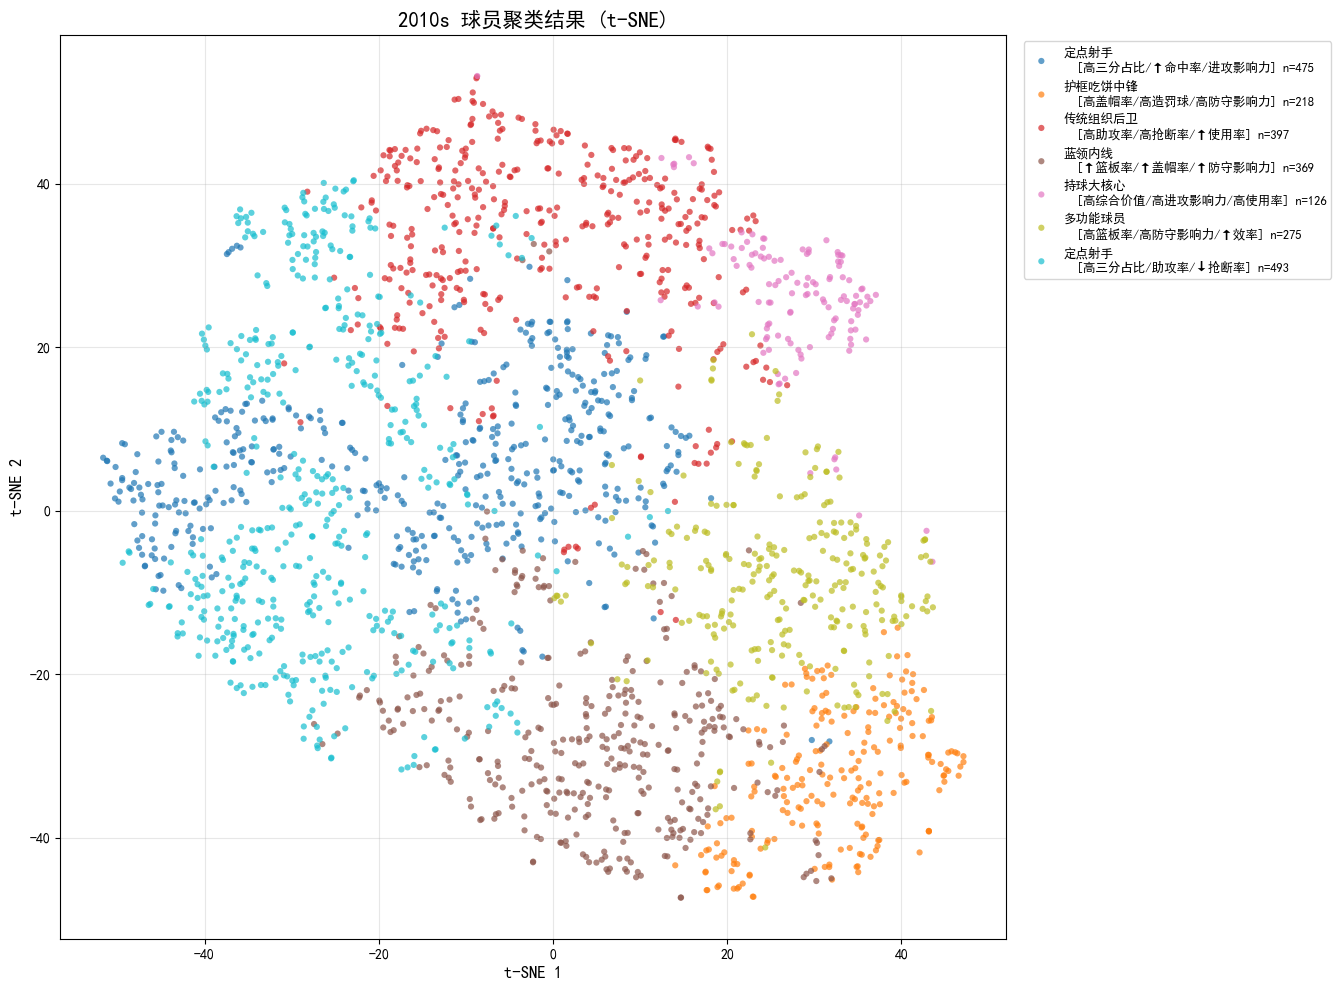

✅ 所有带名称+人数+特点的散点图已生成！


In [71]:
def get_cluster_characteristics(cluster_id, result, top_n=3):
    """
    获取某个簇的突出特点（高/低特征）
    
    Parameters:
    - cluster_id: 簇ID
    - result: 聚类结果字典
    - top_n: 显示前N个突出特征
    
    Returns:
    - 特征字符串，如 "高使用率/高助攻率/高效率"
    """
    df = result['data']
    features = CLUSTER_FEATURES
    
    # 获取该簇的特征均值
    cluster_data = df[df['Cluster'] == cluster_id]
    cluster_profile = cluster_data[features].mean()
    
    # 获取所有簇的全局均值和标准差
    all_profiles = df.groupby('Cluster')[features].mean()
    global_mean = all_profiles.mean()
    global_std = all_profiles.std()
    
    # 计算该簇每个特征的Z-score（相对于其他簇）
    z_scores = {}
    for f in features:
        if global_std[f] > 0:
            z_scores[f] = (cluster_profile[f] - global_mean[f]) / global_std[f]
        else:
            z_scores[f] = 0
    
    # 中文字段名映射
    label_map = {
        'PER': '效率', 'TS%': '命中率', 'USG%': '使用率',
        '3PAr': '三分占比', 'FTr': '造罚球', 'AST%': '助攻率',
        'TRB%': '篮板率', 'STL%': '抢断率', 'BLK%': '盖帽率',
        'OBPM': '进攻影响力', 'DBPM': '防守影响力', 'VORP': '综合价值'
    }
    
    # 选出Z-score最高的特征（突出特点）
    sorted_features = sorted(z_scores.items(), key=lambda x: x[1], reverse=True)
    
    feature_strs = []
    for f, z in sorted_features[:top_n]:
        f_name = label_map.get(f, f)
        if z > 0.8:
            prefix = "高"
        elif z > 0.3:
            prefix = "↑"
        elif z < -0.8:
            prefix = "低"
        elif z < -0.3:
            prefix = "↓"
        else:
            prefix = ""
        feature_strs.append(f"{prefix}{f_name}")
    
    return "/".join(feature_strs)


def visualize_clusters_with_names_and_features(result, cluster_names, method='tsne', save_path=None):
    """
    绘制带聚类名称 + 人数 + 特点的散点图
    """
    era = result['era']
    X_scaled = result['X_scaled']
    labels = result['labels']
    n_clusters = result['n_clusters']
    
    # 降维
    if method == 'pca':
        reducer = PCA(n_components=2)
        X_2d = reducer.fit_transform(X_scaled)
        method_name = 'PCA'
        x_label = f"PC1 ({reducer.explained_variance_ratio_[0]:.1%})"
        y_label = f"PC2 ({reducer.explained_variance_ratio_[1]:.1%})"
    else:  # tsne
        if len(X_scaled) > 3000:
            np.random.seed(42)
            idx = np.random.choice(len(X_scaled), 3000, replace=False)
            X_sample = X_scaled[idx]
            labels_sample = labels[idx]
        else:
            X_sample = X_scaled
            labels_sample = labels
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        X_2d = tsne.fit_transform(X_sample)
        method_name = 't-SNE'
        x_label = 't-SNE 1'
        y_label = 't-SNE 2'
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(14, 10))
    
    unique_clusters = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
    
    # 为每个簇单独绘制
    for idx, cluster_id in enumerate(unique_clusters):
        mask = (labels == cluster_id)
        cluster_name = cluster_names.get(cluster_id, f"Cluster {cluster_id}")
        count = np.sum(mask)
        
        # 获取该簇的特点
        characteristics = get_cluster_characteristics(cluster_id, result, top_n=3)
        
        # 构建图例标签：名称 + 人数 + 特点
        if characteristics:
            legend_label = f'{cluster_name}\n  [{characteristics}] n={count}'
        else:
            legend_label = f'{cluster_name} (n={count})'
        
        X_cluster = X_2d[mask]
        ax.scatter(X_cluster[:, 0], X_cluster[:, 1],
                   c=[colors[idx]], label=legend_label,
                   alpha=0.7, s=20, edgecolors='none')
    
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(f'{era} 球员聚类结果 ({method_name})', fontsize=15, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0), fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    
    return fig


# ============================================================
# 执行
# ============================================================

for era, result in era_results.items():
    visualize_clusters_with_names_and_features(
        result, 
        era_cluster_names[era], 
        method='pca',
        save_path=f'../figures/clustering_pca_feature_{era}.png'
    )

for era, result in era_results.items():
    visualize_clusters_with_names_and_features(
        result, 
        era_cluster_names[era], 
        method='tsne',
        save_path=f'../figures/clustering_tsne_feature_{era}.png'
    )

print("✅ 所有带名称+人数+特点的散点图已生成！")

### 3. 聚类语义画像（核心产出）


#### 3.1 计算各簇特征均值

In [72]:
def compute_cluster_profiles(result):
    """计算每个簇的特征均值，用于画像命名"""
    era = result['era']
    df = result['data']
    features = CLUSTER_FEATURES
    
    # 计算各簇特征均值
    profiles = df.groupby('Cluster')[features].mean()
    
    # 计算各簇样本量
    counts = df['Cluster'].value_counts().sort_index()
    profiles['Count'] = counts
    
    print(f"\n{'='*60}")
    print(f"{era} 各簇特征均值:")
    print('='*60)
    print(profiles.round(3))
    
    return profiles

# 计算所有年代的簇画像
era_profiles = {}
for era, result in era_results.items():
    era_profiles[era] = compute_cluster_profiles(result)


1980s 各簇特征均值:
            PER    TS%    USG%   3PAr    FTr    AST%    TRB%   STL%   BLK%  \
Cluster                                                                      
0        12.750  0.509  18.570  0.085  0.255  21.292   5.445  2.148  0.413   
1        11.539  0.513  16.076  0.010  0.337   7.872  13.108  1.280  2.065   
2        16.558  0.580  19.021  0.007  0.453   9.168  14.733  1.360  2.162   
3        20.791  0.565  23.503  0.052  0.370  25.984   9.299  2.662  1.038   
4        16.981  0.546  24.294  0.035  0.316  14.777   7.975  1.622  0.653   

          OBPM   DBPM   VORP  Count  
Cluster                              
0       -0.824 -0.954  0.221    624  
1       -2.277  0.855  0.349    584  
2        0.441  1.078  2.059    397  
3        3.545  0.973  4.537    173  
4        1.235 -1.263  1.207    427  

1990s 各簇特征均值:
            PER    TS%    USG%   3PAr    FTr    AST%    TRB%   STL%   BLK%  \
Cluster                                                                      
0

#### 3.2 自动命名函数

In [73]:
# 命名函数（和原来一样）
def name_cluster(profile):
    """根据特征模式自动命名聚类"""
    usg = profile.get('USG%', 0)
    ts = profile.get('TS%', 0)
    three_par = profile.get('3PAr', 0)
    ast = profile.get('AST%', 0)
    trb = profile.get('TRB%', 0)
    blk = profile.get('BLK%', 0)
    stl = profile.get('STL%', 0)
    per = profile.get('PER', 0)
    dbpm = profile.get('DBPM', 0)
    
    # 持球核心（高USG + 高AST）
    if usg > 25 and ast > 20:
        if blk > 3 and trb > 12:
            return "组织中锋"
        elif three_par > 0.35:
            return "持球双能卫"
        else:
            return "持球大核心"
    
    # 3D球员（高3PAr + 低USG）
    if three_par > 0.35 and usg < 22:
        if stl > 1.5 and dbpm > 0:
            if blk > 2:
                return "3D空间内线"
            else:
                return "3D侧翼"
        else:
            return "定点射手"
    
    # 防守尖兵
    if stl > 2.0 and usg < 20 and per < 16:
        return "防守尖兵"
    
    # 护框内线
    if blk > 2.5 and trb > 12 and three_par < 0.15:
        if usg > 20 and ts > 0.55:
            return "攻防一体中锋"
        else:
            return "护框吃饼中锋"
    
    # 空间内线
    if three_par > 0.3 and trb > 8 and blk > 1:
        return "空间型内线"
    
    # 高效得分手
    if ts > 0.58 and usg > 22:
        return "高效得分手"
    
    # 传统组织后卫
    if ast > 20 and usg < 25:
        return "传统组织后卫"
    
    # 蓝领内线
    if trb > 10 and usg < 18 and per < 15:
        return "蓝领内线"
    
    # 角色球员
    if per < 13 and usg < 18:
        return "角色轮换"
    
    return "多功能球员"

# 计算各簇画像并命名
era_cluster_names = {}
era_profiles = {}

for era, result in era_results.items():
    df = result['data']
    features = CLUSTER_FEATURES
    
    profiles = df.groupby('Cluster')[features].mean()
    profiles['Count'] = df['Cluster'].value_counts().sort_index()
    
    era_profiles[era] = profiles
    
    # 命名
    names = {}
    for cluster_id in profiles.index:
        if cluster_id != 'Count':
            names[cluster_id] = name_cluster(profiles.loc[cluster_id])
    era_cluster_names[era] = names
    
    # 打印
    print(f"\n{'='*60}")
    print(f"{era} 聚类命名 (K={result['n_clusters']}, 轮廓系数={result['silhouette_score']:.4f})")
    print('='*60)
    for cid, name in names.items():
        count = len(df[df['Cluster'] == cid])
        print(f"  Cluster {cid}: {name} (n={count})")


1980s 聚类命名 (K=5, 轮廓系数=0.1625)
  Cluster 0: 防守尖兵 (n=624)
  Cluster 1: 蓝领内线 (n=584)
  Cluster 2: 多功能球员 (n=397)
  Cluster 3: 传统组织后卫 (n=173)
  Cluster 4: 多功能球员 (n=427)

1990s 聚类命名 (K=5, 轮廓系数=0.1493)
  Cluster 0: 传统组织后卫 (n=307)
  Cluster 1: 蓝领内线 (n=685)
  Cluster 2: 多功能球员 (n=537)
  Cluster 3: 防守尖兵 (n=604)
  Cluster 4: 攻防一体中锋 (n=411)

2000s 聚类命名 (K=6, 轮廓系数=0.1528)
  Cluster 0: 定点射手 (n=725)
  Cluster 1: 护框吃饼中锋 (n=291)
  Cluster 2: 角色轮换 (n=534)
  Cluster 3: 攻防一体中锋 (n=244)
  Cluster 4: 多功能球员 (n=601)
  Cluster 5: 传统组织后卫 (n=391)

2010s 聚类命名 (K=7, 轮廓系数=0.1498)
  Cluster 0: 定点射手 (n=475)
  Cluster 1: 护框吃饼中锋 (n=218)
  Cluster 2: 传统组织后卫 (n=397)
  Cluster 3: 蓝领内线 (n=369)
  Cluster 4: 持球大核心 (n=126)
  Cluster 5: 多功能球员 (n=275)
  Cluster 6: 定点射手 (n=493)


#### 3.3 生成完整的聚类画像表

In [74]:
def generate_cluster_table(result, cluster_names):
    """生成包含样本量、命名和特征的完整画像表"""
    era = result['era']
    df = result['data']
    features = CLUSTER_FEATURES
    
    # 计算各簇均值 + 样本量
    profiles = df.groupby('Cluster')[features].mean()
    profiles['Count'] = df['Cluster'].value_counts().sort_index()
    profiles['Cluster_Name'] = profiles.index.map(lambda x: cluster_names.get(x, f"Cluster {x}"))
    
    # 重新排列列顺序
    cols = ['Cluster_Name', 'Count'] + features
    profiles = profiles[cols]
    
    return profiles

# 生成所有年代的画像表
for era, result in era_results.items():
    print(f"\n{'='*80}")
    print(f"{era} 聚类画像完整表")
    print('='*80)
    table = generate_cluster_table(result, era_cluster_names[era])
    print(table.round(3))


1980s 聚类画像完整表
        Cluster_Name  Count     PER    TS%    USG%   3PAr    FTr    AST%  \
Cluster                                                                    
0               防守尖兵    624  12.750  0.509  18.570  0.085  0.255  21.292   
1               蓝领内线    584  11.539  0.513  16.076  0.010  0.337   7.872   
2              多功能球员    397  16.558  0.580  19.021  0.007  0.453   9.168   
3             传统组织后卫    173  20.791  0.565  23.503  0.052  0.370  25.984   
4              多功能球员    427  16.981  0.546  24.294  0.035  0.316  14.777   

           TRB%   STL%   BLK%   OBPM   DBPM   VORP  
Cluster                                             
0         5.445  2.148  0.413 -0.824 -0.954  0.221  
1        13.108  1.280  2.065 -2.277  0.855  0.349  
2        14.733  1.360  2.162  0.441  1.078  2.059  
3         9.299  2.662  1.038  3.545  0.973  4.537  
4         7.975  1.622  0.653  1.235 -1.263  1.207  

1990s 聚类画像完整表
        Cluster_Name  Count     PER    TS%    USG%   3PAr    FTr  

### 4. 各簇球员特征对比雷达图（核心交付物）


#### 4.1 绘制各簇雷达图（用于输出图片）

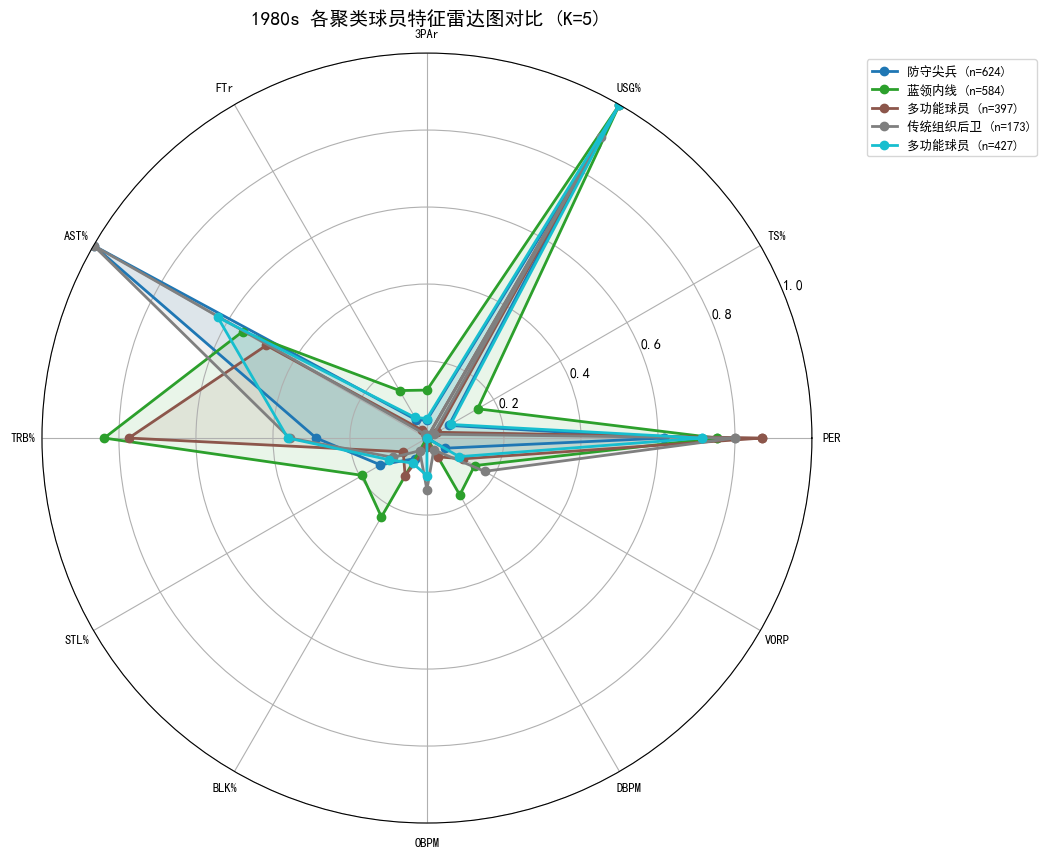

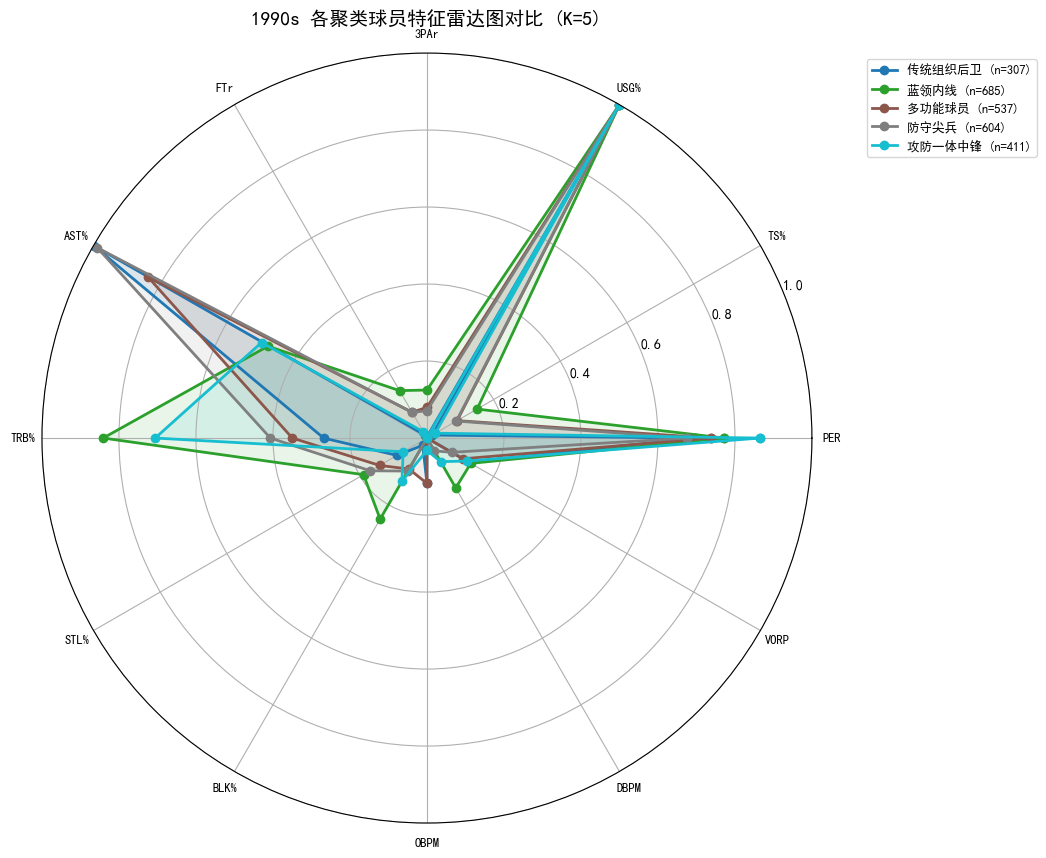

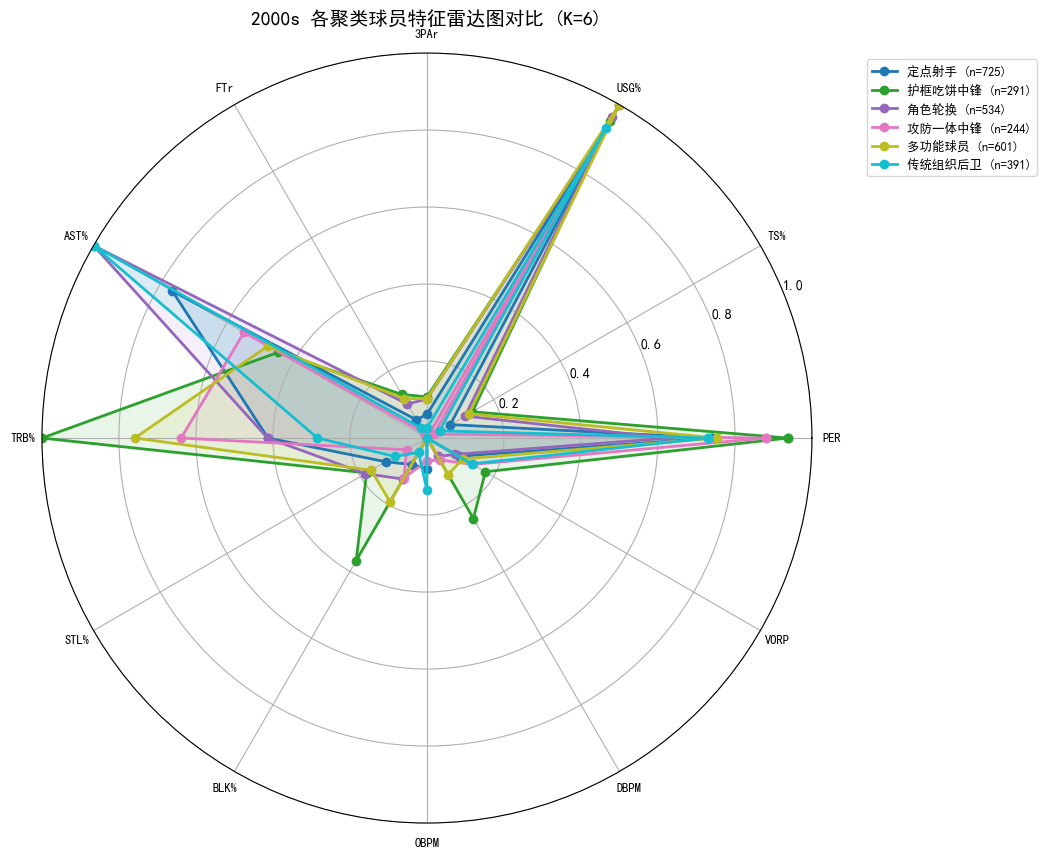

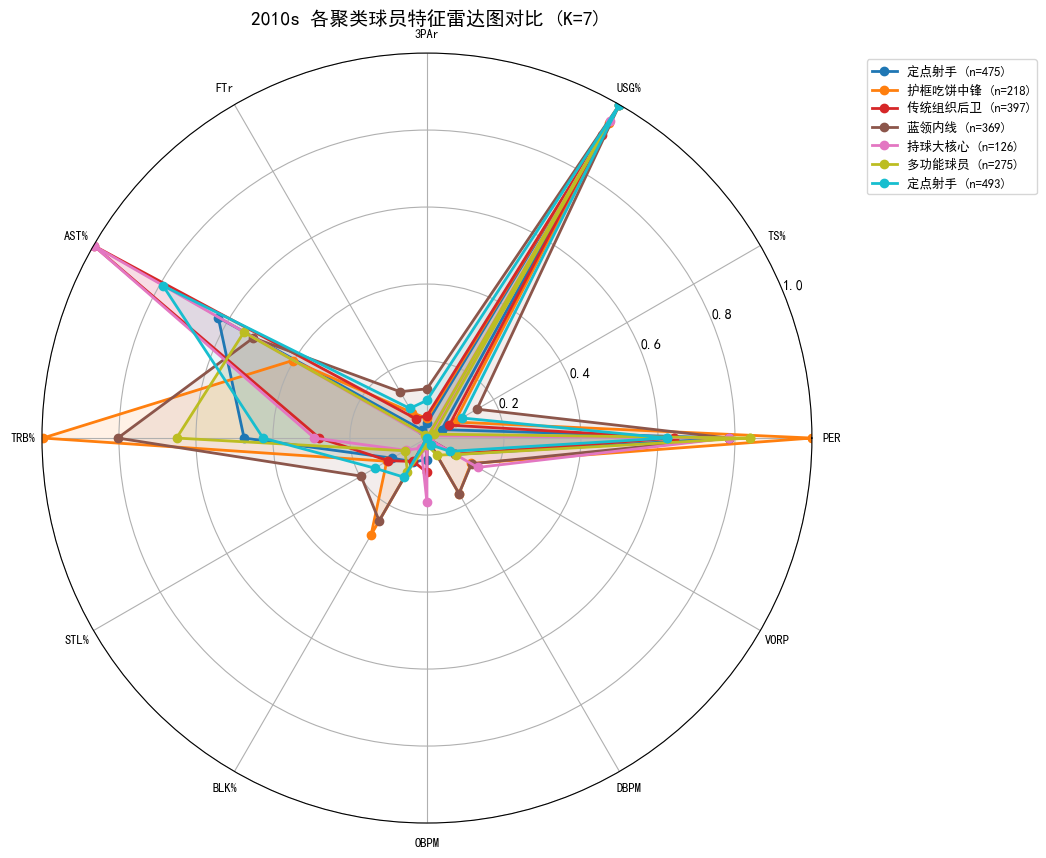

In [75]:
def plot_cluster_radar(result, cluster_names, save_path=None):
    """绘制各簇雷达图"""
    era = result['era']
    df = result['data']
    features = CLUSTER_FEATURES
    
    profiles = df.groupby('Cluster')[features].mean()
    
    scaler = MinMaxScaler()
    profiles_norm = pd.DataFrame(
        scaler.fit_transform(profiles.T).T,
        index=profiles.index,
        columns=profiles.columns
    )
    
    n_features = len(features)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(profiles)))
    
    for i, (cluster_id, profile) in enumerate(profiles_norm.iterrows()):
        values = profile.tolist() + profile.tolist()[:1]
        cluster_name = cluster_names.get(cluster_id, f"Cluster {cluster_id}")
        count = len(df[df['Cluster'] == cluster_id])
        ax.plot(angles, values, 'o-', linewidth=2, 
                label=f'{cluster_name} (n={count})', 
                color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, size=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'{era} 各聚类球员特征雷达图对比 (K={result["n_clusters"]})', size=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
    ax.grid(True)
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

# 绘制所有年代的雷达图
for era, result in era_results.items():
    plot_cluster_radar(result, era_cluster_names[era], 
                       save_path=f'../figures/clustering_radar_manual_{era}.png')

#### 4.2 生成各簇雷达图的独立文件（供角色E使用）

In [76]:
def plot_individual_cluster_radars(result, cluster_names, output_dir='../figures/clusters/'):
    """
    为每个簇单独生成雷达图（用于Web看板展示）
    """
    era = result['era']
    df = result['data']
    features = CLUSTER_FEATURES
    
    # 计算簇中心
    profiles = df.groupby('Cluster')[features].mean()
    
    # 归一化
    scaler = MinMaxScaler()
    profiles_norm = pd.DataFrame(
        scaler.fit_transform(profiles.T).T,
        index=profiles.index,
        columns=profiles.columns
    )
    
    n_features = len(features)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]
    
    os.makedirs(output_dir, exist_ok=True)
    
    for cluster_id, profile in profiles_norm.iterrows():
        cluster_name = cluster_names.get(cluster_id, f"Cluster {cluster_id}")
        count = len(df[df['Cluster'] == cluster_id])
        
        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
        
        values = profile.tolist() + profile.tolist()[:1]
        ax.plot(angles, values, 'o-', linewidth=3, color='#1f77b4')
        ax.fill(angles, values, alpha=0.3, color='#1f77b4')
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(features, size=10)
        ax.set_ylim(0, 1)
        ax.set_title(f'{cluster_name}\n{era} | n={count}', size=12, pad=20)
        ax.grid(True)
        
        # 保存
        safe_name = cluster_name.replace('/', '_').replace(' ', '_')
        plt.savefig(f'{output_dir}/{era}_{safe_name}.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"已保存: {output_dir}/{era}_{safe_name}.png")

# 生成所有簇的独立雷达图
for era, result in era_results.items():
    plot_individual_cluster_radars(result, era_cluster_names[era])

已保存: ../figures/clusters//1980s_防守尖兵.png
已保存: ../figures/clusters//1980s_蓝领内线.png
已保存: ../figures/clusters//1980s_多功能球员.png
已保存: ../figures/clusters//1980s_传统组织后卫.png
已保存: ../figures/clusters//1980s_多功能球员.png
已保存: ../figures/clusters//1990s_传统组织后卫.png
已保存: ../figures/clusters//1990s_蓝领内线.png
已保存: ../figures/clusters//1990s_多功能球员.png
已保存: ../figures/clusters//1990s_防守尖兵.png
已保存: ../figures/clusters//1990s_攻防一体中锋.png
已保存: ../figures/clusters//2000s_定点射手.png
已保存: ../figures/clusters//2000s_护框吃饼中锋.png
已保存: ../figures/clusters//2000s_角色轮换.png
已保存: ../figures/clusters//2000s_攻防一体中锋.png
已保存: ../figures/clusters//2000s_多功能球员.png
已保存: ../figures/clusters//2000s_传统组织后卫.png
已保存: ../figures/clusters//2010s_定点射手.png
已保存: ../figures/clusters//2010s_护框吃饼中锋.png
已保存: ../figures/clusters//2010s_传统组织后卫.png
已保存: ../figures/clusters//2010s_蓝领内线.png
已保存: ../figures/clusters//2010s_持球大核心.png
已保存: ../figures/clusters//2010s_多功能球员.png
已保存: ../figures/clusters//2010s_定点射手.png


### 5. 年代演变分析

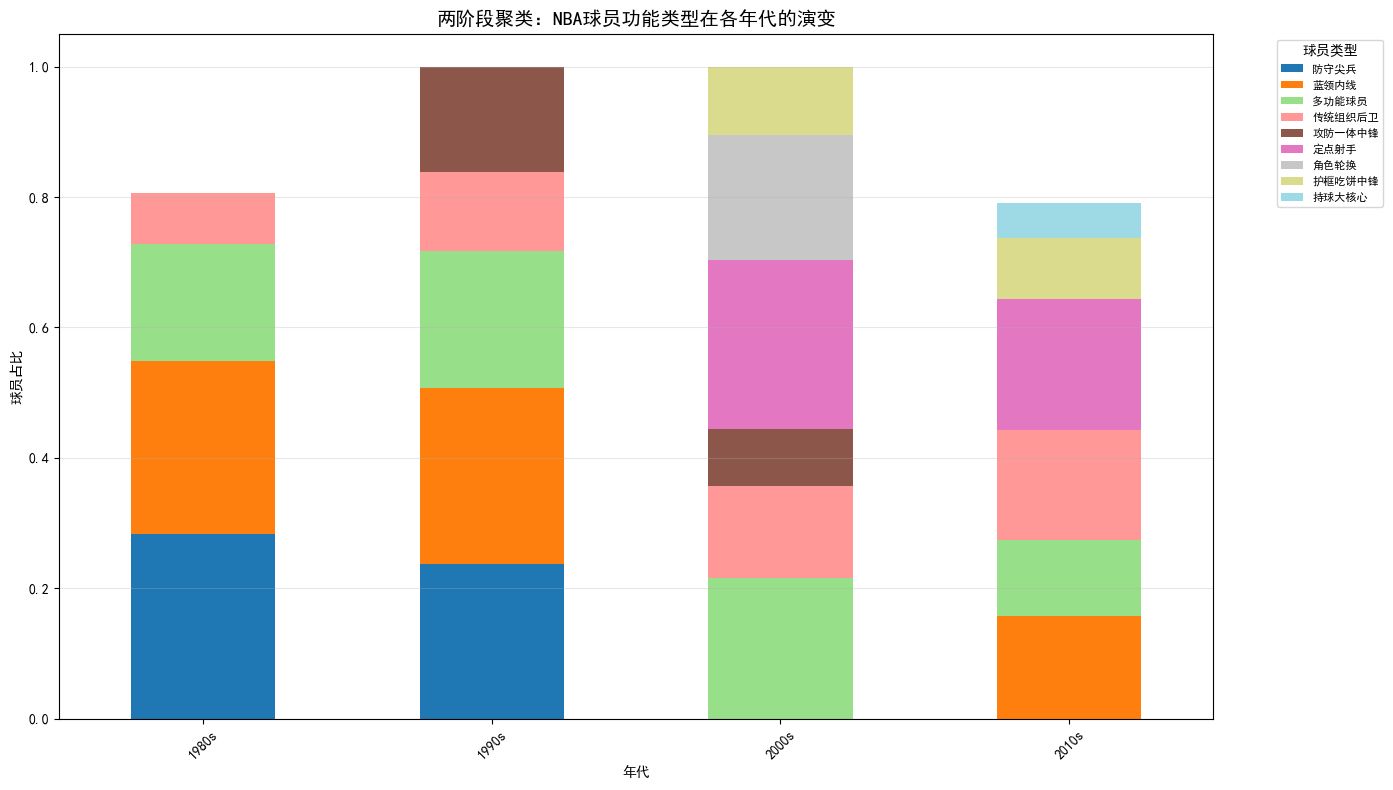

In [77]:
def analyze_two_stage_evolution(era_results, era_cluster_names):
    """分析两阶段聚类后各细簇在各年代的比例变化"""
    all_names = set()
    for names in era_cluster_names.values():
        all_names.update(names.values())
    all_names = list(all_names)
    
    era_dist = {}
    for era, result in era_results.items():
        df = result['data']
        names = era_cluster_names[era]
        dist = df['Cluster'].value_counts(normalize=True)
        era_dist[era] = {names.get(cid, f"Cluster {cid}"): dist.get(cid, 0) 
                         for cid in dist.index}
    
    df_evolution = pd.DataFrame(era_dist).T.fillna(0)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    df_evolution.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
    ax.set_title('两阶段聚类：NBA球员功能类型在各年代的演变', fontsize=14)
    ax.set_xlabel('年代')
    ax.set_ylabel('球员占比')
    ax.legend(title='球员类型', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_xticklabels(df_evolution.index, rotation=45)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../figures/clustering_era_evolution_two_stage.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return df_evolution

df_evolution = analyze_two_stage_evolution(era_results, era_cluster_names)

### 6. 保存结果（交付角色E）


#### 6.1 保存聚类标签到CSV

In [78]:
# 保存聚类标签
def save_cluster_labels(era_results, era_cluster_names):
    all_labels = []
    for era, result in era_results.items():
        df = result['data'].copy()
        names = era_cluster_names[era]
        df['Cluster_Name'] = df['Cluster'].map(lambda x: names.get(x, f"Cluster {x}"))
        df['Era'] = era
        all_labels.append(df[['Year', 'Player', 'Pos', 'Tm', 'Era', 'Cluster', 'Cluster_Name']])
    
    combined = pd.concat(all_labels, ignore_index=True)
    os.makedirs('../data/processed', exist_ok=True)
    combined.to_csv('../data/processed/player_clusters_manual.csv', index=False)
    print(f"聚类标签已保存: {len(combined)} 条记录")
    return combined

combined_labels = save_cluster_labels(era_results, era_cluster_names)

# 保存簇信息
def save_cluster_info(era_results, era_cluster_names):
    cluster_info = {}
    for era, result in era_results.items():
        df = result['data']
        names = era_cluster_names[era]
        features = CLUSTER_FEATURES
        
        cluster_info[era] = {}
        for cluster_id in df['Cluster'].unique():
            cluster_data = df[df['Cluster'] == cluster_id]
            top_players = cluster_data.nlargest(5, 'PER')[['Player', 'Year']].values.tolist()
            profile = cluster_data[features].mean()
            
            cluster_info[era][str(cluster_id)] = {
                'name': names.get(cluster_id, f"Cluster {cluster_id}"),
                'count': len(cluster_data),
                'representatives': [{'name': p[0], 'year': int(p[1])} for p in top_players],
                'profile': profile.to_dict()
            }
    
    os.makedirs('../saved_models', exist_ok=True)
    with open('../saved_models/cluster_info_manual.json', 'w', encoding='utf-8') as f:
        json.dump(cluster_info, f, ensure_ascii=False, indent=2)
    print("簇信息已保存")
    return cluster_info

cluster_info = save_cluster_info(era_results, era_cluster_names)

聚类标签已保存: 9888 条记录
簇信息已保存


#### 6.2 保存簇信息（供角色E展示）

In [79]:
def save_cluster_info(era_results, era_cluster_names):
    """保存簇的详细信息（名称、描述、代表球员）"""
    cluster_info = {}
    
    for era, result in era_results.items():
        df = result['data']
        names = era_cluster_names[era]
        features = CLUSTER_FEATURES
        
        cluster_info[era] = {}
        for cluster_id in df['Cluster'].unique():
            cluster_data = df[df['Cluster'] == cluster_id]
            
            # 找代表球员（该簇中PER最高的5人）
            top_players = cluster_data.nlargest(5, 'PER')[['Player', 'Year']].values.tolist()
            
            # 计算特征描述
            profile = cluster_data[features].mean()
            
            cluster_info[era][str(cluster_id)] = {
                'name': names.get(cluster_id, f"Cluster {cluster_id}"),
                'count': len(cluster_data),
                'representatives': [{'name': p[0], 'year': int(p[1])} for p in top_players],
                'profile': profile.to_dict()
            }
    
    # 保存为JSON
    os.makedirs('../saved_models', exist_ok=True)
    with open('../saved_models/cluster_info.json', 'w', encoding='utf-8') as f:
        json.dump(cluster_info, f, ensure_ascii=False, indent=2)
    
    print("簇信息已保存到 ../saved_models/cluster_info.json")
    return cluster_info

cluster_info = save_cluster_info(era_results, era_cluster_names)

簇信息已保存到 ../saved_models/cluster_info.json
